In [1]:
%pip install requests pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import requests
import pandas as pd
from datetime import datetime

BASE_URL = "https://api.met.gov.my/v2.1/data"

TOKEN = "800b8992bc918dff3b95348ea036e3cf2837b92c"

headers = {
    "Authorization": f"METToken {TOKEN}"
}

params = {
    "datasetid": "FORECAST",
    "datacategoryid": "GENERAL",
    "locationid": "LOCATION:237",  # Putrajaya
    "start_date": datetime.today().strftime("%Y-%m-%d"),
    "end_date": datetime.today().strftime("%Y-%m-%d"),
    "lang": "en"
}

In [10]:
response = requests.get(BASE_URL, headers=headers, params=params)

print("Status Code:", response.status_code)

data = response.json()

data

Status Code: 200


{'metadata': {'resultset': {'count': 6,
   'offset': 0,
   'limit': 50,
   'locationid': 'LOCATION:237',
   'datasetid': 'FORECAST',
   'datacategoryid': 'GENERAL'}},
 'results': [{'locationid': 'LOCATION:237',
   'locationname': 'PUTRAJAYA',
   'locationrootid': 'LOCATION:12',
   'locationrootname': 'PUTRAJAYA',
   'date': '2026-03-09T00:00:00+08:00',
   'datatype': 'FGM',
   'value': 'No Rain',
   'latitude': 2.91667,
   'longitude': 101.7,
   'attributes': {'ref': None,
    'valid_from': '2026-03-09T11:10:00+08:00',
    'valid_to': None}},
  {'locationid': 'LOCATION:237',
   'locationname': 'PUTRAJAYA',
   'locationrootid': 'LOCATION:12',
   'locationrootname': 'PUTRAJAYA',
   'date': '2026-03-09T00:00:00+08:00',
   'datatype': 'FGA',
   'value': 'No Rain',
   'latitude': 2.91667,
   'longitude': 101.7,
   'attributes': {'ref': None,
    'valid_from': '2026-03-09T12:40:00+08:00',
    'valid_to': None}},
  {'locationid': 'LOCATION:237',
   'locationname': 'PUTRAJAYA',
   'locationroo

In [11]:
results = data.get("results", [])

df = pd.json_normalize(results)

df

,locationid,locationname,locationrootid,locationrootname,date,datatype,value,latitude,longitude,attributes.ref,attributes.valid_from,attributes.valid_to,attributes.unit,attributes.code,attributes.when
0,LOCATION:237,PUTRAJAYA,LOCATION:12,PUTRAJAYA,2026-03-09T00:00:00+08:00,FGM,No Rain,2.91667,101.7,None,2026-03-09T11:10:00+08:00,None,NaN,NaN,NaN
1,LOCATION:237,PUTRAJAYA,LOCATION:12,PUTRAJAYA,2026-03-09T00:00:00+08:00,FGA,No Rain,2.91667,101.7,None,2026-03-09T12:40:00+08:00,None,NaN,NaN,NaN
2,LOCATION:237,PUTRAJAYA,LOCATION:12,PUTRAJAYA,2026-03-09T00:00:00+08:00,FGN,No rain,2.91667,101.7,None,None,None,NaN,NaN,NaN
3,LOCATION:237,PUTRAJAYA,LOCATION:12,PUTRAJAYA,2026-03-09T00:00:00+08:00,FMAXT,34,2.91667,101.7,None,None,None,Celcius,NaN,NaN
4,LOCATION:237,PUTRAJAYA,LOCATION:12,PUTRAJAYA,2026-03-09T00:00:00+08:00,FMINT,23,2.91667,101.7,None,None,None,Celcius,NaN,NaN
5,LOCATION:237,PUTRAJAYA,LOCATION:12,PUTRAJAYA,2026-03-09T00:00:00+08:00,FSIGW,No rain,2.91667,101.7,None,None,None,NaN,sunny,Whole Day


In [12]:
forecast_df = df[[
    "locationname",
    "date",
    "datatype",
    "value",
    "attributes.unit",
    "latitude",
    "longitude"
]]

forecast_df

,locationname,date,datatype,value,attributes.unit,latitude,longitude
0,PUTRAJAYA,2026-03-09T00:00:00+08:00,FGM,No Rain,NaN,2.91667,101.7
1,PUTRAJAYA,2026-03-09T00:00:00+08:00,FGA,No Rain,NaN,2.91667,101.7
2,PUTRAJAYA,2026-03-09T00:00:00+08:00,FGN,No rain,NaN,2.91667,101.7
3,PUTRAJAYA,2026-03-09T00:00:00+08:00,FMAXT,34,Celcius,2.91667,101.7
4,PUTRAJAYA,2026-03-09T00:00:00+08:00,FMINT,23,Celcius,2.91667,101.7
5,PUTRAJAYA,2026-03-09T00:00:00+08:00,FSIGW,No rain,NaN,2.91667,101.7


In [13]:
pivot_df = forecast_df.pivot_table(
    index=["locationname", "date"],
    columns="datatype",
    values="value",
    aggfunc="first"
).reset_index()

pivot_df

datatype,locationname,date,FGA,FGM,FGN,FMAXT,FMINT,FSIGW
0,PUTRAJAYA,2026-03-09T00:00:00+08:00,No Rain,No Rain,No rain,34,23,No rain


In [14]:
params["locationid"] = "ALL_LOCATIONS"

response = requests.get(BASE_URL, headers=headers, params=params)

data = response.json()

df_all = pd.json_normalize(data["results"])

df_all.head()

,locationid,locationname,locationrootid,locationrootname,date,datatype,value,latitude,longitude,attributes.ref,attributes.valid_from,attributes.valid_to,attributes.code,attributes.when,attributes.unit
0,LOCATION:291,RAWANG,LOCATION:15,SELANGOR,2026-03-09T00:00:00+08:00,FGA,Rain,3.32130,101.57670,None,2026-03-09T14:40:00+08:00,None,NaN,NaN,NaN
1,LOCATION:289,KUALA KUBU BHARU,LOCATION:15,SELANGOR,2026-03-09T00:00:00+08:00,FGA,No Rain,3.56380,101.65810,None,2026-03-09T14:40:00+08:00,None,NaN,NaN,NaN
2,LOCATION:310,BATU FERINGGI,LOCATION:9,PULAU PINANG,2026-03-09T00:00:00+08:00,FGA,Rain,5.47090,100.24529,None,2026-03-09T14:30:00+08:00,None,NaN,NaN,NaN
3,LOCATION:323,PULAU LANGKAWI,LOCATION:2,KEDAH,2026-03-09T00:00:00+08:00,FGA,No Rain,6.36667,99.80000,None,2026-03-09T14:00:00+08:00,None,NaN,NaN,NaN
4,LOCATION:124,JOHOR BAHRU,LOCATION:1,JOHOR,2026-03-09T00:00:00+08:00,FGA,No Rain,1.46550,103.75780,None,2026-03-09T14:00:00+08:00,None,NaN,NaN,NaN


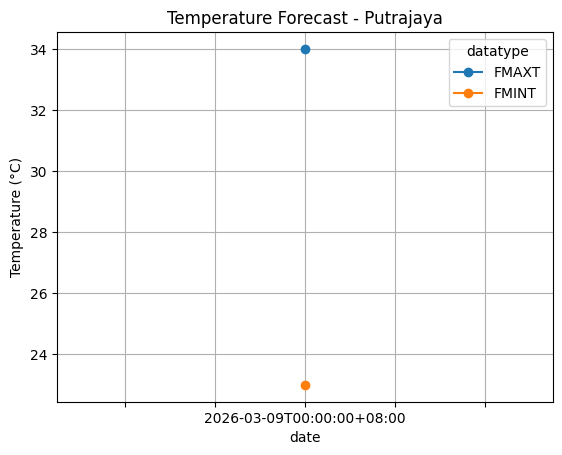

In [15]:
import matplotlib.pyplot as plt

pivot_df.plot(
    x="date",
    y=["FMAXT","FMINT"],
    kind="line",
    marker="o"
)

plt.title("Temperature Forecast - Putrajaya")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()